# 04_01 Baseline model comparison

Maturity-aware rolling-origin evaluation of eight transparent baselines, with the same-weekday moving average as the reference benchmark.

## Fixed evaluation design

A product-store series is evaluated at an origin only when it has at least 28 observed/open days strictly before that origin. Forecasts cover seven calendar days at weekly Monday origins, capped at 20 origins.

The same-weekday moving average with recent-mean fallback is the benchmark. Every challenger uses the same assessed origins, target observations, and metric reducers.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.baseline import BASELINE_MODEL_LABELS
from src.models.benchmark import (
    MODEL_COLUMNS, PRIMARY_MODEL, load_benchmark_design,
    segment_wape, summarize_models,
)
from src.models.results import load_benchmark_result

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid', context='notebook')


## Model definitions

- **Recent mean:** mean of the last 28 observed/open days.
- **Same-weekday moving average:** mean of the last four matching weekdays, with recent mean fallback. This is the benchmark.
- **Occurrence × positive quantity:** recent occurrence rate multiplied by the mean of the last ten positive quantities.
- **ETS(A,N,N) / SES:** fixed smoothing level α = 0.2.
- **Croston:** positive-demand size and inter-demand interval smoothed with α = 0.1.
- **SBA:** Croston multiplied by `(1 - α / 2) = 0.95`.
- **TSB:** positive size and occurrence probability separately smoothed with α = 0.1.
- **Aggregate then disaggregate:** mean of the last four origin-aligned seven-day totals, distributed by weekday shares from the last eight weeks; equal 1/7 shares are used for a zero-volume profile.

Every state, mean, and profile uses only observations with `date < origin`.

In [ ]:
design = load_benchmark_design()
result = load_benchmark_result(design, include_extended_baselines=True)
forecasts = result.forecasts[result.forecasts['is_active']].copy()

MODEL_LABELS = {**MODEL_COLUMNS, **BASELINE_MODEL_LABELS}
MODEL_ORDER = [*MODEL_COLUMNS, *BASELINE_MODEL_LABELS]
SHORT_LABELS = {
    'recent_mean': 'Recent mean',
    'same_weekday_moving_average': 'Same weekday',
    'occurrence_x_positive_quantity': 'Occurrence x quantity',
    'simple_exponential_smoothing': 'SES',
    'croston': 'Croston',
    'sba': 'SBA',
    'tsb': 'TSB',
    'aggregate_then_disaggregate': 'Aggregate to weekday',
}

print(design)
print(f'Complete origins: {forecasts.origin.nunique():,}')
print(f'Mature series evaluated at least once: {len(forecasts[["ARTIKEL_ID", "MARKT_ID"]].drop_duplicates()):,}')
print(f'Baseline models: {forecasts.model.nunique():,}')
display(result.origin_summary)


BenchmarkDesign(min_active_days=28, first_origin=Timestamp('2026-03-02 00:00:00'), origin_spacing_days=7, forecast_horizon_days=7, max_origins=20, data_dir=PosixPath('/Users/vlada/UNI/SoSe2026/ba/ba_code/data/processed/transactions'))
Complete origins: 20
Mature series evaluated at least once: 21,937
Baseline models: 8


,origin,known_series,assessed_series,assessed_fcm_series,assessed_pseudo_series,evaluated_series
0,2026-03-02,21695.0,21443,2838.0,18605.0,21443
1,2026-03-09,21702.0,21590,2978.0,18612.0,21590
2,2026-03-16,21706.0,21614,2993.0,18621.0,21614
3,2026-03-23,21825.0,21628,3004.0,18624.0,21628
4,2026-03-30,21839.0,21690,3004.0,18686.0,21690
5,2026-04-06,21843.0,21697,3006.0,18691.0,21697
6,2026-04-13,21883.0,21702,3007.0,18695.0,21702
7,2026-04-20,21910.0,21711,3008.0,18703.0,21711
8,2026-04-27,21916.0,21828,3011.0,18817.0,21828
9,2026-05-04,21923.0,21839,3015.0,18824.0,21839


## Overall performance

Lower pooled WAPE is better. Bias near zero is better; negative values mean underforecasting.

In [ ]:
summary = summarize_models(forecasts)
summary['model_label'] = summary.model.map(MODEL_LABELS)
summary['model_order'] = pd.Categorical(summary.model, MODEL_ORDER, ordered=True)
summary = summary.sort_values('model_order').drop(columns='model_order')
summary_table = summary[[
    'model_label', 'pooled_wape', 'relative_bias', 'forecast_to_actual_ratio',
    'median_series_wape', 'seasonal_mase', 'mae_kg', 'mean_bias_kg',
    'actual_kg', 'forecast_kg', 'n_series', 'n_origins', 'n_forecast_rows',
]]
display(summary_table.style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'median_series_wape': '{:.2%}',
    'seasonal_mase': '{:.3f}', 'mae_kg': '{:.3f}', 'mean_bias_kg': '{:+.3f}',
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}',
    'n_series': '{:,.0f}', 'n_origins': '{:,.0f}', 'n_forecast_rows': '{:,.0f}',
}))

,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,median_series_wape,seasonal_mase,mae_kg,mean_bias_kg,actual_kg,forecast_kg,n_series,n_origins,n_forecast_rows
0,Recent mean (28 observations),97.93%,-17.49%,0.825,132.23%,0.894,0.996,-0.178,"2,552,925.9","2,106,495.5","21,937",20,"2,511,229"
1,Same-weekday moving average (4 occurrences; recent-mean fallback),102.59%,+0.52%,1.005,141.91%,0.932,1.043,+0.005,"2,552,925.9","2,566,096.8","21,937",20,"2,511,229"
2,Occurrence x positive quantity,112.10%,+3.59%,1.036,143.55%,0.970,1.140,+0.036,"2,552,925.9","2,644,565.2","21,937",20,"2,511,229"
3,"ETS (A,N,N) / simple exponential smoothing",103.58%,-20.67%,0.793,134.28%,0.919,1.053,-0.210,"2,552,925.9","2,025,176.1","21,937",20,"2,511,229"
4,Croston,106.66%,-6.22%,0.938,134.81%,1.015,1.084,-0.063,"2,552,925.9","2,394,081.7","21,937",20,"2,511,229"
5,SBA (bias-adjusted Croston),104.66%,-10.91%,0.891,132.64%,0.997,1.064,-0.111,"2,552,925.9","2,274,377.6","21,937",20,"2,511,229"
6,TSB,99.67%,-17.83%,0.822,132.86%,0.900,1.013,-0.181,"2,552,925.9","2,097,659.9","21,937",20,"2,511,229"
7,Aggregate then disaggregate (7-day total x weekday profile),101.18%,+0.51%,1.005,140.25%,0.919,1.029,+0.005,"2,552,925.9","2,565,973.0","21,937",20,"2,511,229"


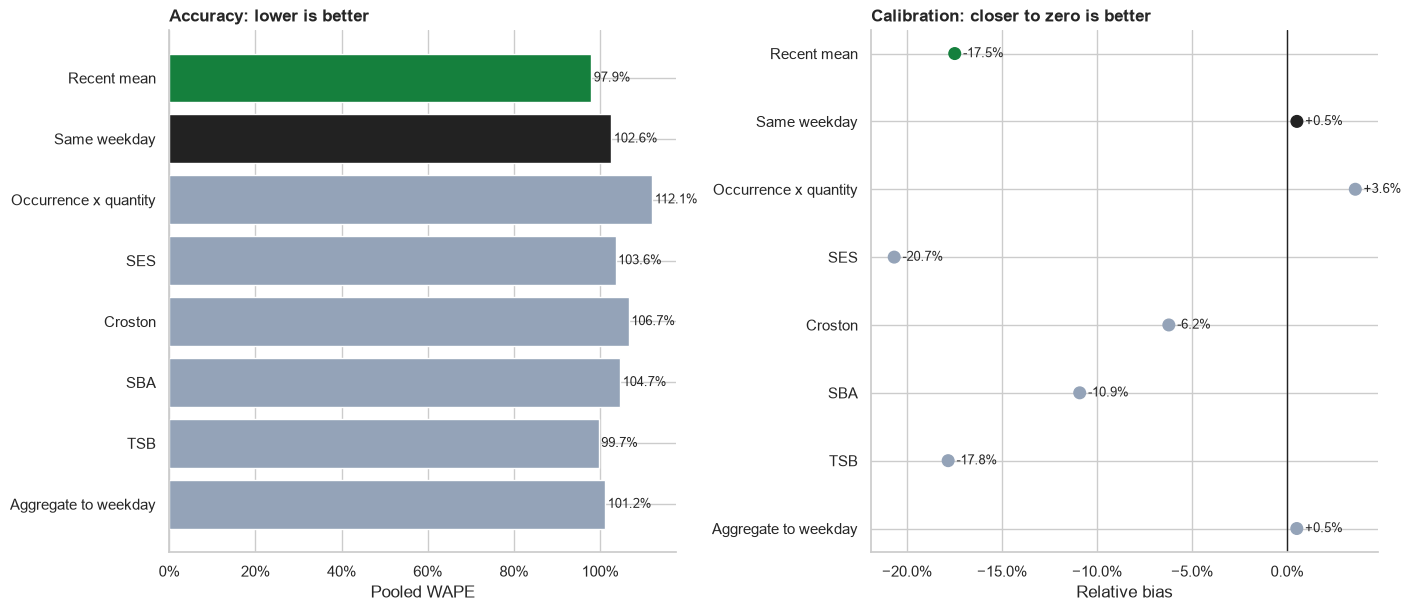

In [ ]:
plot_summary = summary.copy()
plot_summary['short_label'] = plot_summary.model.map(SHORT_LABELS)
best_challenger_model = (
    plot_summary.loc[~plot_summary.model.eq(PRIMARY_MODEL)]
    .sort_values('pooled_wape')
    .iloc[0].model
)
colors = [
    '#222222' if model == PRIMARY_MODEL else '#15803d' if model == best_challenger_model else '#94a3b8'
    for model in plot_summary.model
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].barh(plot_summary.short_label, plot_summary.pooled_wape, color=colors)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_xlabel('Pooled WAPE')
axes[0].set_ylabel('')
axes[0].set_title('Accuracy: lower is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.pooled_wape):
    axes[0].text(value + 0.006, y, f'{value:.1%}', va='center', fontsize=9)

axes[1].axvline(0, color='#222222', linewidth=1)
axes[1].scatter(plot_summary.relative_bias, plot_summary.short_label, c=colors, s=70, zorder=3)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel('Relative bias')
axes[1].set_ylabel('')
axes[1].set_title('Calibration: closer to zero is better', loc='left', weight='bold')
for y, value in enumerate(plot_summary.relative_bias):
    axes[1].annotate(f'{value:+.1%}', (value, y), xytext=(6, 0), textcoords='offset points', va='center', fontsize=9)
sns.despine(fig=fig)
plt.show()

In [ ]:
benchmark_row = summary.loc[summary.model.eq(PRIMARY_MODEL)].iloc[0]
best_challenger = summary.loc[summary.model.eq(best_challenger_model)].iloc[0]
overall_gain_pp = 100 * (benchmark_row.pooled_wape - best_challenger.pooled_wape)
print(
    f'Best challenger: {best_challenger.model_label}\n'
    f'WAPE: {best_challenger.pooled_wape:.2%} vs {benchmark_row.pooled_wape:.2%} for the benchmark '
    f'({overall_gain_pp:+.2f} percentage points better).\n'
    f'Bias: {best_challenger.relative_bias:+.2%} vs {benchmark_row.relative_bias:+.2%} for the benchmark.'
)

Best challenger: Recent mean (28 observations)
WAPE: 97.93% vs 102.59% for the benchmark (+4.66 percentage points better).
Bias: -17.49% vs +0.52% for the benchmark.


## Was the benchmark beaten at individual origins?

Each cell is challenger WAPE minus benchmark WAPE in percentage points. Negative values mean the challenger won at that origin.

In [ ]:
origin_results = segment_wape(forecasts, 'origin')
origin_wape = origin_results.pivot(index='model', columns='origin', values='pooled_wape')
origin_delta = origin_wape.drop(index=PRIMARY_MODEL).sub(origin_wape.loc[PRIMARY_MODEL], axis=1)
origin_win_summary = pd.DataFrame({
    'model': origin_delta.index,
    'origins_won': origin_delta.lt(0).sum(axis=1).to_numpy(),
    'origins_evaluated': origin_delta.notna().sum(axis=1).to_numpy(),
    'mean_wape_delta': origin_delta.mean(axis=1).to_numpy(),
    'best_origin_delta': origin_delta.min(axis=1).to_numpy(),
})
origin_win_summary['win_rate'] = origin_win_summary.origins_won / origin_win_summary.origins_evaluated
origin_win_summary['model_label'] = origin_win_summary.model.map(MODEL_LABELS)
origin_win_summary = origin_win_summary.sort_values(
    ['origins_won', 'mean_wape_delta'], ascending=[False, True]
)
display(origin_win_summary[[
    'model_label', 'origins_won', 'origins_evaluated', 'win_rate',
    'mean_wape_delta', 'best_origin_delta',
]].style.format({
    'origins_won': '{:,.0f}', 'origins_evaluated': '{:,.0f}', 'win_rate': '{:.0%}',
    'mean_wape_delta': '{:+.2%}', 'best_origin_delta': '{:+.2%}',
}))

winning = origin_win_summary.loc[origin_win_summary.origins_won.gt(0)]
if winning.empty:
    print('No challenger beats the benchmark at any origin.')
else:
    print(f'Yes. {len(winning)} challenger(s) beat the benchmark at least once.')

,model_label,origins_won,origins_evaluated,win_rate,mean_wape_delta,best_origin_delta
3,Recent mean (28 observations),16,20,80%,-5.14%,-15.93%
0,Aggregate then disaggregate (7-day total x weekday profile),15,20,75%,-1.44%,-11.83%
6,TSB,14,20,70%,-3.38%,-16.19%
5,"ETS (A,N,N) / simple exponential smoothing",9,20,45%,+0.66%,-14.66%
4,SBA (bias-adjusted Croston),9,20,45%,+1.73%,-7.54%
1,Croston,3,20,15%,+3.83%,-4.57%
2,Occurrence x positive quantity,0,20,0%,+9.55%,+1.94%


Yes. 6 challenger(s) beat the benchmark at least once.


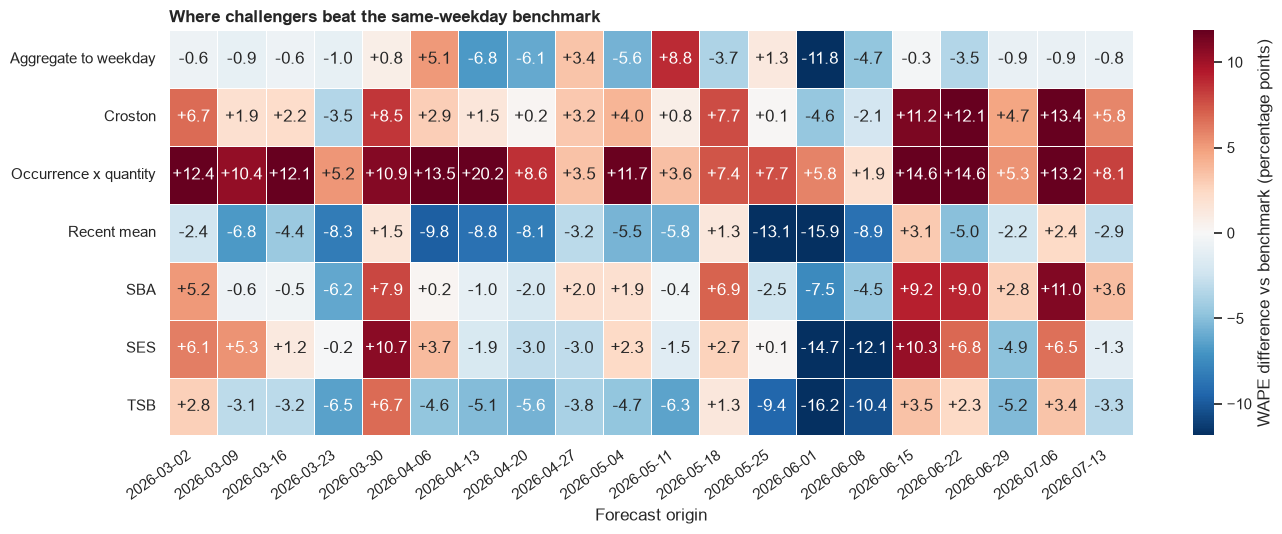

In [ ]:
heatmap = origin_delta.copy() * 100
heatmap.index = heatmap.index.map(SHORT_LABELS)
heatmap.columns = [pd.Timestamp(origin).strftime('%Y-%m-%d') for origin in heatmap.columns]
color_limit = max(5, min(25, float(np.nanpercentile(np.abs(heatmap), 90))))
plt.figure(figsize=(14, 5.5))
sns.heatmap(
    heatmap, annot=True, fmt='+.1f', cmap='RdBu_r', center=0,
    vmin=-color_limit, vmax=color_limit, linewidths=0.5,
    cbar_kws={'label': 'WAPE difference vs benchmark (percentage points)'},
)
plt.xlabel('Forecast origin')
plt.ylabel('')
plt.title('Where challengers beat the same-weekday benchmark', loc='left', weight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## Was the benchmark beaten within business segments?

For each source-group × merchandise segment, the comparison below selects the lowest-WAPE challenger. Positive improvement means the benchmark was outperformed. Demand volume is shown because low-volume segments can produce unstable percentages.

In [ ]:
segment_cols = ['sourcing_group', 'category_id']
segment_results = segment_wape(forecasts, segment_cols)
segment_wide = segment_results.pivot(index=segment_cols, columns='model', values='pooled_wape')
challenger_cols = [model for model in MODEL_ORDER if model != PRIMARY_MODEL]
best_model = segment_wide[challenger_cols].idxmin(axis=1)
best_wape = segment_wide[challenger_cols].min(axis=1)
segment_volume = (
    segment_results.loc[segment_results.model.eq(PRIMARY_MODEL)]
    .set_index(segment_cols)['actual_kg']
)
segment_comparison = pd.DataFrame({
    'benchmark_wape': segment_wide[PRIMARY_MODEL],
    'best_challenger': best_model.map(MODEL_LABELS),
    'best_challenger_wape': best_wape,
    'improvement_pp': 100 * (segment_wide[PRIMARY_MODEL] - best_wape),
    'actual_kg': segment_volume,
}).reset_index()
display(segment_comparison.style.format({
    'benchmark_wape': '{:.2%}', 'best_challenger_wape': '{:.2%}',
    'improvement_pp': '{:+.2f}', 'actual_kg': '{:,.1f}',
}))

,sourcing_group,category_id,benchmark_wape,best_challenger,best_challenger_wape,improvement_pp,actual_kg
0,FCM,890,198.85%,"ETS (A,N,N) / simple exponential smoothing",160.90%,+37.95,"3,840.1"
1,FCM,900,100.64%,TSB,93.33%,+7.31,"56,737.4"
2,Pseudo,890,102.47%,Recent mean (28 observations),97.88%,+4.59,"2,489,426.8"
3,Pseudo,900,115.88%,"ETS (A,N,N) / simple exponential smoothing",93.78%,+22.10,"2,921.6"


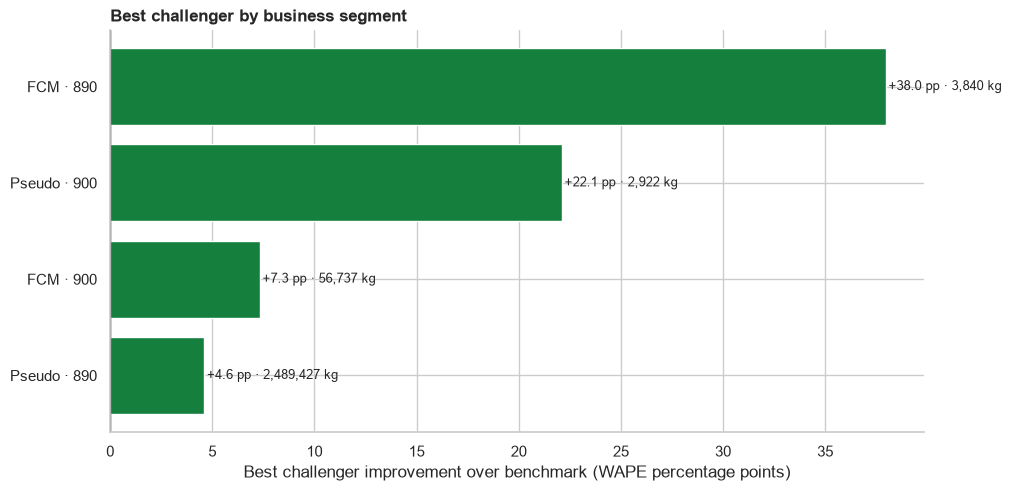

In [ ]:
segment_plot = segment_comparison.copy()
segment_plot['segment'] = (
    segment_plot.sourcing_group + ' · ' + segment_plot.category_id.astype(str)
)
segment_plot = segment_plot.sort_values('improvement_pp')
bar_colors = np.where(segment_plot.improvement_pp.gt(0), '#15803d', '#b91c1c')
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
ax.barh(segment_plot.segment, segment_plot.improvement_pp, color=bar_colors)
ax.axvline(0, color='#222222', linewidth=1)
ax.set_xlabel('Best challenger improvement over benchmark (WAPE percentage points)')
ax.set_ylabel('')
ax.set_title('Best challenger by business segment', loc='left', weight='bold')
for y, row in enumerate(segment_plot.itertuples()):
    offset = 0.15 if row.improvement_pp >= 0 else -0.15
    alignment = 'left' if row.improvement_pp >= 0 else 'right'
    ax.text(
        row.improvement_pp + offset, y,
        f'{row.improvement_pp:+.1f} pp · {row.actual_kg:,.0f} kg',
        va='center', ha=alignment, fontsize=9,
    )
sns.despine(ax=ax)
plt.show()

## Why is WAPE so high for FCM 890?

WAPE is `sum(abs(forecast - actual)) / sum(actual)`. A large value can therefore come from an unusually small actual-demand denominator, large forecast errors, or both. The following checks separate denominator size, future sparsity, pre-origin demand recency, error type, and error concentration.

In [ ]:
target_keys = ['ARTIKEL_ID', 'MARKT_ID', 'sourcing_group', 'category_id', 'origin', 'period']
target_population = (
    forecasts.sort_values('model')
    .drop_duplicates(target_keys)
    .copy()
)
target_population['has_target_demand'] = target_population.actual.gt(0)
series_origin = (
    target_population.groupby(
        ['sourcing_group', 'category_id', 'ARTIKEL_ID', 'MARKT_ID', 'origin'],
        observed=True,
    )
    .agg(
        actual_kg=('actual', 'sum'),
        target_rows=('actual', 'size'),
        positive_target_rows=('has_target_demand', 'sum'),
        recent_occurrence_rate=('recent_occurrence_rate', 'first'),
        calendar_days_since_last_demand=('calendar_days_since_last_demand', 'first'),
        demand_days_before_origin=('demand_days_before_origin', 'first'),
    )
    .reset_index()
)
series_origin['has_target_demand'] = series_origin.actual_kg.gt(0)
series_origin['no_recent_demand'] = series_origin.recent_occurrence_rate.eq(0)
series_origin['last_demand_over_28_days'] = series_origin.calendar_days_since_last_demand.gt(28)
series_origin['near_maturity_floor'] = series_origin.demand_days_before_origin.le(15)

segment_activity = (
    series_origin.groupby(['sourcing_group', 'category_id'], observed=True)
    .agg(
        actual_kg=('actual_kg', 'sum'),
        series_origins=('actual_kg', 'size'),
        target_rows=('target_rows', 'sum'),
        positive_target_rows=('positive_target_rows', 'sum'),
        no_demand_horizon_share=('has_target_demand', lambda values: 1 - values.mean()),
        no_recent_demand_share=('no_recent_demand', 'mean'),
        stale_over_28_days_share=('last_demand_over_28_days', 'mean'),
        near_maturity_floor_share=('near_maturity_floor', 'mean'),
        median_recent_occurrence=('recent_occurrence_rate', 'median'),
        median_days_since_demand=('calendar_days_since_last_demand', 'median'),
    )
    .reset_index()
)
segment_activity['zero_target_row_share'] = (
    1 - segment_activity.positive_target_rows / segment_activity.target_rows
)
display(segment_activity[[
    'sourcing_group', 'category_id', 'actual_kg', 'series_origins',
    'zero_target_row_share', 'no_demand_horizon_share',
    'no_recent_demand_share', 'stale_over_28_days_share',
    'near_maturity_floor_share', 'median_recent_occurrence',
    'median_days_since_demand',
]].style.format({
    'actual_kg': '{:,.1f}', 'series_origins': '{:,.0f}',
    'zero_target_row_share': '{:.1%}', 'no_demand_horizon_share': '{:.1%}',
    'no_recent_demand_share': '{:.1%}', 'stale_over_28_days_share': '{:.1%}',
    'near_maturity_floor_share': '{:.1%}', 'median_recent_occurrence': '{:.1%}',
    'median_days_since_demand': '{:.0f}',
}))

,sourcing_group,category_id,actual_kg,series_origins,zero_target_row_share,no_demand_horizon_share,no_recent_demand_share,stale_over_28_days_share,near_maturity_floor_share,median_recent_occurrence,median_days_since_demand
0,FCM,890,"3,840.1","5,727",92.3%,76.4%,49.0%,49.0%,4.3%,4.3%,27
1,FCM,900,"56,737.4","54,827",58.5%,26.8%,10.9%,10.9%,4.6%,41.7%,3
2,Pseudo,890,"2,489,426.8","371,877",62.2%,34.6%,13.5%,13.5%,0.4%,31.8%,3
3,Pseudo,900,"2,921.6","3,508",68.5%,44.2%,21.7%,21.7%,13.3%,30.4%,4


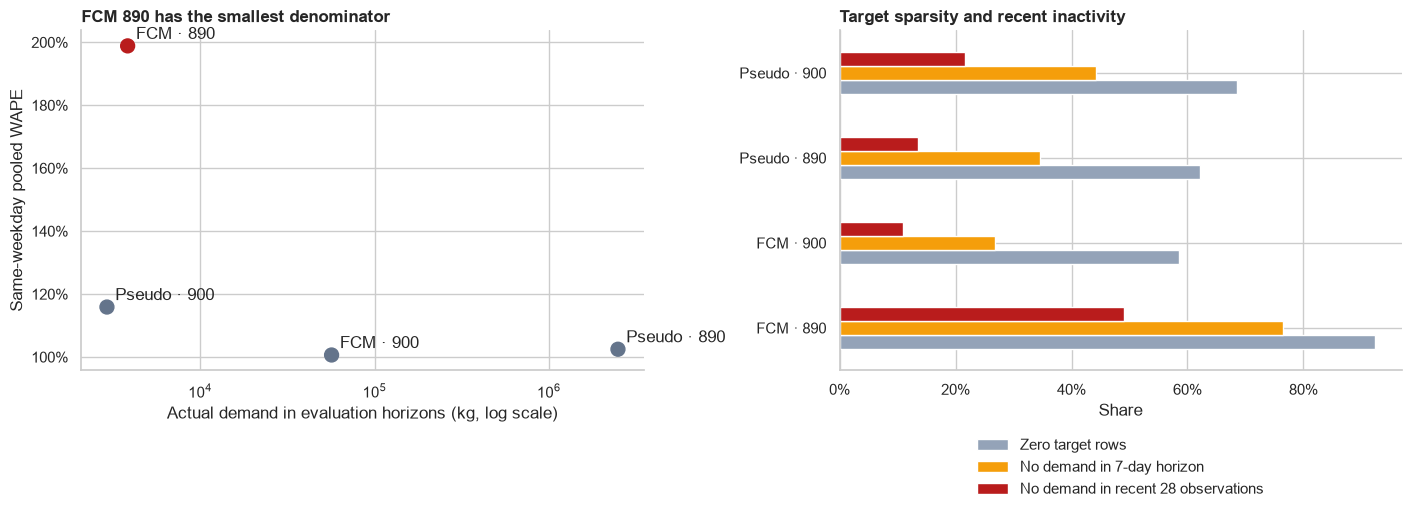

In [ ]:
benchmark_segments = (
    segment_results.loc[segment_results.model.eq(PRIMARY_MODEL)]
    .merge(segment_activity, on=['sourcing_group', 'category_id'], suffixes=('', '_activity'))
)
benchmark_segments['segment'] = (
    benchmark_segments.sourcing_group + ' · ' + benchmark_segments.category_id.astype(str)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].scatter(
    benchmark_segments.actual_kg, benchmark_segments.pooled_wape,
    s=100, c=['#b91c1c' if segment == 'FCM · 890' else '#64748b' for segment in benchmark_segments.segment],
)
for row in benchmark_segments.itertuples():
    axes[0].annotate(row.segment, (row.actual_kg, row.pooled_wape), xytext=(6, 5), textcoords='offset points')
axes[0].set_xscale('log')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_xlabel('Actual demand in evaluation horizons (kg, log scale)')
axes[0].set_ylabel('Same-weekday pooled WAPE')
axes[0].set_title('FCM 890 has the smallest denominator', loc='left', weight='bold')

activity_plot = segment_activity.copy()
activity_plot['segment'] = activity_plot.sourcing_group + ' · ' + activity_plot.category_id.astype(str)
activity_plot = activity_plot.set_index('segment')[[
    'zero_target_row_share', 'no_demand_horizon_share', 'no_recent_demand_share',
]]
activity_plot.columns = ['Zero target rows', 'No demand in 7-day horizon', 'No demand in recent 28 observations']
activity_plot.plot.barh(ax=axes[1], color=['#94a3b8', '#f59e0b', '#b91c1c'])
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel('Share')
axes[1].set_ylabel('')
axes[1].set_title('Target sparsity and recent inactivity', loc='left', weight='bold')
axes[1].legend(
    frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1,
)
sns.despine(fig=fig)
plt.show()

### Error decomposition across all models

On a zero-demand target row, every positive forecast becomes absolute error. Splitting the WAPE numerator by zero and positive target rows shows whether models mainly miss demand sizes or predict demand that does not occur.

In [ ]:
fcm890 = forecasts.loc[
    forecasts.sourcing_group.eq('FCM') & forecasts.category_id.eq(890)
].copy()
fcm890['abs_error'] = (fcm890.forecast - fcm890.actual).abs()
fcm890['zero_target_abs_error'] = np.where(fcm890.actual.eq(0), fcm890.abs_error, 0.0)
fcm890['positive_target_abs_error'] = np.where(fcm890.actual.gt(0), fcm890.abs_error, 0.0)
error_decomposition = (
    fcm890.groupby('model', observed=True)
    .agg(
        actual_kg=('actual', 'sum'),
        forecast_kg=('forecast', 'sum'),
        absolute_error_kg=('abs_error', 'sum'),
        error_on_zero_targets_kg=('zero_target_abs_error', 'sum'),
        error_on_positive_targets_kg=('positive_target_abs_error', 'sum'),
    )
    .reset_index()
)
error_decomposition['wape'] = error_decomposition.absolute_error_kg / error_decomposition.actual_kg
error_decomposition['forecast_to_actual_ratio'] = error_decomposition.forecast_kg / error_decomposition.actual_kg
error_decomposition['zero_target_error_share'] = (
    error_decomposition.error_on_zero_targets_kg / error_decomposition.absolute_error_kg
)
error_decomposition['model_label'] = error_decomposition.model.map(MODEL_LABELS)
error_decomposition['model_order'] = pd.Categorical(error_decomposition.model, MODEL_ORDER, ordered=True)
error_decomposition = error_decomposition.sort_values('model_order').drop(columns='model_order')
display(error_decomposition[[
    'model_label', 'actual_kg', 'forecast_kg', 'absolute_error_kg', 'wape',
    'forecast_to_actual_ratio', 'error_on_zero_targets_kg',
    'error_on_positive_targets_kg', 'zero_target_error_share',
]].style.format({
    'actual_kg': '{:,.1f}', 'forecast_kg': '{:,.1f}', 'absolute_error_kg': '{:,.1f}',
    'wape': '{:.2%}', 'forecast_to_actual_ratio': '{:.2f}',
    'error_on_zero_targets_kg': '{:,.1f}', 'error_on_positive_targets_kg': '{:,.1f}',
    'zero_target_error_share': '{:.1%}',
}))

,model_label,actual_kg,forecast_kg,absolute_error_kg,wape,forecast_to_actual_ratio,error_on_zero_targets_kg,error_on_positive_targets_kg,zero_target_error_share
3,Recent mean (28 observations),"3,840.1","4,986.6","7,147.6",186.13%,1.30,"4,136.8","3,010.8",57.9%
4,Same-weekday moving average (4 occurrences; recent-mean fallback),"3,840.1","6,161.9","7,636.2",198.85%,1.60,"4,886.4","2,749.9",64.0%
2,Occurrence x positive quantity,"3,840.1","6,025.4","7,866.0",204.84%,1.57,"5,004.4","2,861.6",63.6%
6,"ETS (A,N,N) / simple exponential smoothing","3,840.1","3,993.5","6,178.8",160.90%,1.04,"3,119.0","3,059.9",50.5%
1,Croston,"3,840.1","11,379.5","13,300.1",346.35%,2.96,"10,371.7","2,928.4",78.0%
5,SBA (bias-adjusted Croston),"3,840.1","10,810.5","12,818.9",333.82%,2.82,"9,853.1","2,965.8",76.9%
7,TSB,"3,840.1","4,547.2","6,671.3",173.73%,1.18,"3,665.8","3,005.6",54.9%
0,Aggregate then disaggregate (7-day total x weekday profile),"3,840.1","6,089.6","7,535.7",196.24%,1.59,"4,815.3","2,720.4",63.9%


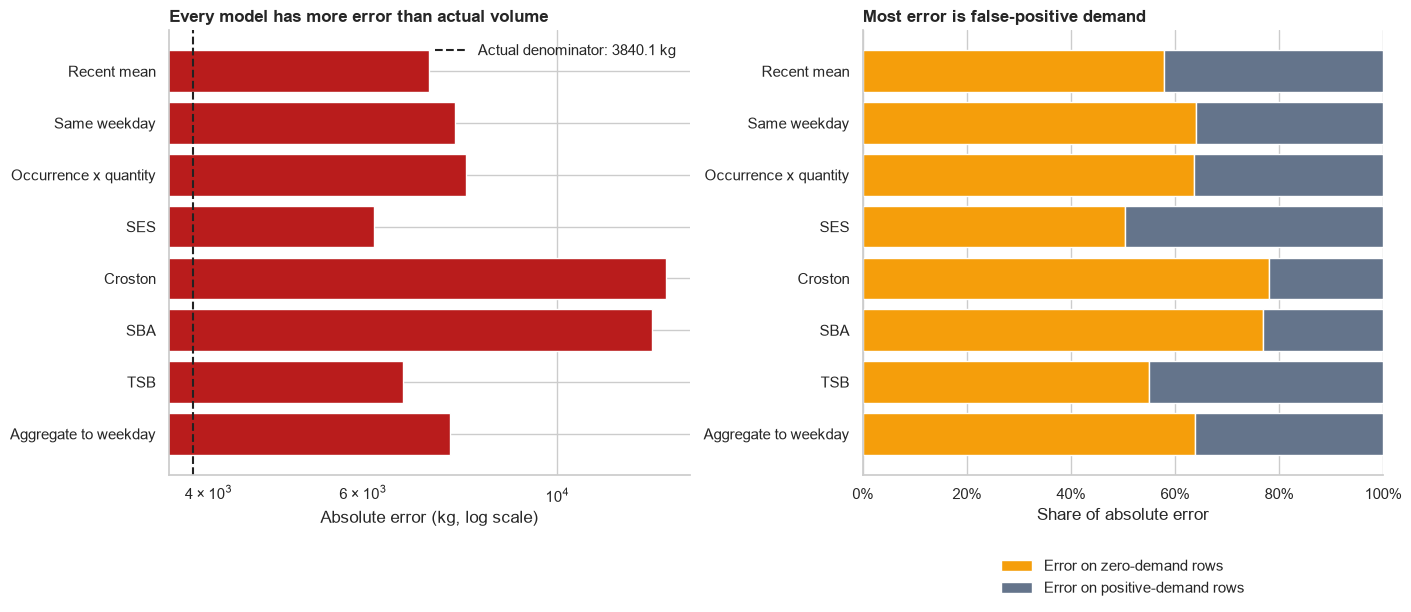

In [ ]:
error_plot = error_decomposition.copy()
error_plot['short_label'] = error_plot.model.map(SHORT_LABELS)
zero_share = error_plot.zero_target_error_share
positive_share = 1 - zero_share

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].barh(error_plot.short_label, error_plot.absolute_error_kg, color='#b91c1c')
axes[0].axvline(error_plot.actual_kg.iloc[0], color='#222222', linestyle='--', label=f'Actual denominator: {error_plot.actual_kg.iloc[0]:.1f} kg')
axes[0].set_xscale('log')
axes[0].invert_yaxis()
axes[0].set_xlabel('Absolute error (kg, log scale)')
axes[0].set_ylabel('')
axes[0].set_title('Every model has more error than actual volume', loc='left', weight='bold')
axes[0].legend(frameon=False)

axes[1].barh(error_plot.short_label, zero_share, color='#f59e0b', label='Error on zero-demand rows')
axes[1].barh(error_plot.short_label, positive_share, left=zero_share, color='#64748b', label='Error on positive-demand rows')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Share of absolute error')
axes[1].set_ylabel('')
axes[1].set_title('Most error is false-positive demand', loc='left', weight='bold')
axes[1].legend(
    frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1,
)
sns.despine(fig=fig)
plt.show()

### Is the result concentrated in a few series?

In [ ]:
series_errors = (
    fcm890.groupby(['model', 'ARTIKEL_ID', 'MARKT_ID'], observed=True)
    .agg(
        actual_kg=('actual', 'sum'),
        forecast_kg=('forecast', 'sum'),
        absolute_error_kg=('abs_error', 'sum'),
        median_recent_occurrence=('recent_occurrence_rate', 'median'),
        median_days_since_demand=('calendar_days_since_last_demand', 'median'),
    )
    .reset_index()
)
concentration_rows = []
for model, group in series_errors.groupby('model', observed=True):
    ranked = group.sort_values('absolute_error_kg', ascending=False)
    total_error = ranked.absolute_error_kg.sum()
    concentration_rows.append({
        'model': model,
        'top_10_series_error_share': ranked.head(10).absolute_error_kg.sum() / total_error,
        'zero_actual_series_error_share': ranked.loc[ranked.actual_kg.eq(0), 'absolute_error_kg'].sum() / total_error,
        'series': len(ranked),
    })
concentration = pd.DataFrame(concentration_rows)
concentration['model_label'] = concentration.model.map(MODEL_LABELS)
display(concentration[[
    'model_label', 'series', 'top_10_series_error_share', 'zero_actual_series_error_share',
]].sort_values('top_10_series_error_share', ascending=False).style.format({
    'series': '{:,.0f}', 'top_10_series_error_share': '{:.1%}',
    'zero_actual_series_error_share': '{:.1%}',
}))

top_benchmark_errors = (
    series_errors.loc[series_errors.model.eq(PRIMARY_MODEL)]
    .sort_values('absolute_error_kg', ascending=False)
    .head(10)
    .copy()
)
top_benchmark_errors['error_share'] = (
    top_benchmark_errors.absolute_error_kg
    / series_errors.loc[series_errors.model.eq(PRIMARY_MODEL), 'absolute_error_kg'].sum()
)
display(top_benchmark_errors[[
    'ARTIKEL_ID', 'MARKT_ID', 'actual_kg', 'forecast_kg', 'absolute_error_kg',
    'error_share', 'median_recent_occurrence', 'median_days_since_demand',
]].style.format({
    'actual_kg': '{:.2f}', 'forecast_kg': '{:.2f}', 'absolute_error_kg': '{:.2f}',
    'error_share': '{:.1%}', 'median_recent_occurrence': '{:.1%}',
    'median_days_since_demand': '{:.0f}',
}))

,model_label,series,top_10_series_error_share,zero_actual_series_error_share
0,Aggregate then disaggregate (7-day total x weekday profile),318,10.7%,0.4%
4,Same-weekday moving average (4 occurrences; recent-mean fallback),318,10.6%,0.4%
2,Occurrence x positive quantity,318,10.4%,0.3%
3,Recent mean (28 observations),318,10.2%,0.3%
6,"ETS (A,N,N) / simple exponential smoothing",318,10.1%,0.2%
7,TSB,318,9.6%,0.2%
1,Croston,318,8.3%,0.9%
5,SBA (bias-adjusted Croston),318,8.2%,0.8%


,ARTIKEL_ID,MARKT_ID,actual_kg,forecast_kg,absolute_error_kg,error_share,median_recent_occurrence,median_days_since_demand
1567,1425927,1300005,69.60,140.15,201.97,2.6%,25.0%,16
1585,1426349,1100001,75.23,98.75,103.45,1.4%,56.5%,3
1577,1425927,1300021,23.00,60.58,69.60,0.9%,41.7%,9
1568,1425927,1300006,25.61,47.08,67.04,0.9%,33.3%,9
1569,1425927,1300007,26.33,49.58,66.65,0.9%,33.3%,12
1565,1425927,1300003,26.36,43.05,64.97,0.9%,25.0%,17
1579,1425927,1300024,21.74,44.13,61.36,0.8%,26.1%,16
1532,1425927,1100001,25.85,44.13,61.35,0.8%,0.0%,31
1580,1425927,1300025,24.91,46.59,61.00,0.8%,33.3%,12
1573,1425927,1300013,26.08,52.51,54.78,0.7%,50.0%,5


In [ ]:
fcm_activity = segment_activity.loc[
    segment_activity.sourcing_group.eq('FCM') & segment_activity.category_id.eq(890)
].iloc[0]
benchmark_error = error_decomposition.loc[error_decomposition.model.eq(PRIMARY_MODEL)].iloc[0]
benchmark_concentration = concentration.loc[concentration.model.eq(PRIMARY_MODEL)].iloc[0]
print(
    'Diagnosis for FCM 890:\n'
    f'1. The WAPE denominator is only {fcm_activity.actual_kg:,.1f} kg across all 20 horizons.\n'
    f'2. {fcm_activity.zero_target_row_share:.1%} of target rows are zero and '
    f'{fcm_activity.no_demand_horizon_share:.1%} of series-origin horizons have no demand.\n'
    f'3. {fcm_activity.no_recent_demand_share:.1%} of assessed series-origins have no positive demand '
    f'in their last 28 observations; median demand recency is {fcm_activity.median_days_since_demand:.0f} days.\n'
    f'4. {fcm_activity.near_maturity_floor_share:.1%} have only 10–15 lifetime demand days.\n'
    f'5. The same-weekday model produces {benchmark_error.absolute_error_kg:,.1f} kg of error, '
    f'or {benchmark_error.wape:.2%} of the tiny denominator; '
    f'{benchmark_error.zero_target_error_share:.1%} of that error occurs on zero-demand rows.\n'
    f'6. Its ten largest-error series contribute {benchmark_concentration.top_10_series_error_share:.1%} '
    'of the numerator.\n\n'
    'Therefore the large WAPE is mainly a low-volume, highly intermittent evaluation denominator '
    'combined with positive forecasts after demand has gone quiet. It is not evidence that every model '
    'misses large quantities of demand in absolute kg. Croston and SBA are especially extreme because '
    'classic Croston does not decay its rate during trailing zero periods; TSB decays occurrence probability '
    'and is less extreme, but the tiny denominator still makes its WAPE large.'
)

Diagnosis for FCM 890:
1. The WAPE denominator is only 3,840.1 kg across all nine horizons.
2. 92.3% of target rows are zero and 76.4% of series-origin horizons have no demand.
3. 49.0% of assessed series-origins have no positive demand in their last 28 observations; median demand recency is 27 days.
4. 4.3% have only 10–15 lifetime demand days, so they pass the maturity rule even when current demand has gone quiet.
5. The same-weekday model produces 7,636.2 kg of error, or 198.85% of the tiny denominator; 64.0% of that error occurs on zero-demand rows.
6. Its ten largest-error series contribute 10.6% of the numerator.

Therefore the large WAPE is mainly a low-volume, highly intermittent evaluation denominator combined with positive forecasts after demand has gone quiet. It is not evidence that every model misses large quantities of demand in absolute kg. Croston and SBA are especially extreme because classic Croston does not decay its rate during trailing zero periods; TSB decays occu

## Complete source-group × merchandise results

The final table retains all eight baselines rather than only the winning model.

In [ ]:
segment_results['model_label'] = segment_results.model.map(MODEL_LABELS)
segment_results['model_order'] = pd.Categorical(segment_results.model, MODEL_ORDER, ordered=True)
segment_results = segment_results.sort_values(
    ['sourcing_group', 'category_id', 'model_order']
).drop(columns='model_order')
display(segment_results[[
    'sourcing_group', 'category_id', 'model_label', 'pooled_wape',
    'relative_bias', 'forecast_to_actual_ratio', 'actual_kg', 'n_series', 'n_origins',
]].style.format({
    'pooled_wape': '{:.2%}', 'relative_bias': '{:+.2%}',
    'forecast_to_actual_ratio': '{:.3f}', 'actual_kg': '{:,.1f}',
    'n_series': '{:,.0f}', 'n_origins': '{:,.0f}',
}))

,sourcing_group,category_id,model_label,pooled_wape,relative_bias,forecast_to_actual_ratio,actual_kg,n_series,n_origins
3,FCM,890,Recent mean (28 observations),186.13%,+29.86%,1.299,"3,840.1",318,20
4,FCM,890,Same-weekday moving average (4 occurrences; recent-mean fallback),198.85%,+60.46%,1.605,"3,840.1",318,20
2,FCM,890,Occurrence x positive quantity,204.84%,+56.91%,1.569,"3,840.1",318,20
6,FCM,890,"ETS (A,N,N) / simple exponential smoothing",160.90%,+3.99%,1.040,"3,840.1",318,20
1,FCM,890,Croston,346.35%,+196.33%,2.963,"3,840.1",318,20
5,FCM,890,SBA (bias-adjusted Croston),333.82%,+181.52%,2.815,"3,840.1",318,20
7,FCM,890,TSB,173.73%,+18.41%,1.184,"3,840.1",318,20
0,FCM,890,Aggregate then disaggregate (7-day total x weekday profile),196.24%,+58.58%,1.586,"3,840.1",318,20
11,FCM,900,Recent mean (28 observations),94.03%,-15.31%,0.847,"56,737.4","2,756",20
12,FCM,900,Same-weekday moving average (4 occurrences; recent-mean fallback),100.64%,+2.87%,1.029,"56,737.4","2,756",20
